In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5379,ham,Somebody set up a website where you can play h...,NaN,NaN,NaN
262,ham,MY NO. IN LUTON 0125698789 RING ME IF UR AROUN...,NaN,NaN,NaN
2805,ham,Can a not?,NaN,NaN,NaN
2918,ham,Is xy in ur car when u picking me up?,NaN,NaN,NaN
3412,ham,Where do you need to go to get it?,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
# 1. data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
# drop last three cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [8]:
df.sample(5)

,v1,v2
238,ham,"New Theory: Argument wins d SITUATION, but los..."
3192,ham,I will lick up every drop :) are you ready to ...
5435,ham,I'm wif him now buying tix lar...
1156,ham,Hey.. Something came up last min.. Think i wun...
2481,ham,K.:)do it at evening da:)urgent:)


In [9]:
# renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
1937,ham,The fact that you're cleaning shows you know w...
4233,ham,Now only i reached home. . . I am very tired n...
767,ham,"Sorry, I'll call later"
1004,ham,Umma. Did she say anything
5239,ham,"Jay wants to work out first, how's 4 sound?"


In [10]:
#LabelEncoder() ek aisi machine hai jo naam ko number me badalti hai aur wapas number ko naam me bhi badal sakti hai.
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

animals = ['dog', 'cat', 'dog', 'fish', 'cat']

# Machine se kaam karwao
encoded_animals = encoder.fit_transform(animals)
print(encoded_animals)


ModuleNotFoundError: No module named 'sklearn'

In [11]:
encoder.inverse_transform([1, 0, 1, 2, 0])


NameError: name 'encoder' is not defined

In [12]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

ModuleNotFoundError: No module named 'sklearn'

In [13]:
df['target']=encoder.fit_transform(df['target'])

NameError: name 'encoder' is not defined

In [14]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
#DataFrame ke har column me kitni missing values (null/NaN) hain, wo count karke dikhaao.
df.isnull().sum()

target    0
text      0
dtype: int64

In [16]:
# yaani kitni duplicate rows hain.
df.duplicated().sum()

403

In [17]:
df=df.drop_duplicates(keep='first')

In [18]:
df.duplicated().sum()

0

In [19]:
df.shape

(5169, 2)

## EDA

In [20]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
df['target'].value_counts

<bound method IndexOpsMixin.value_counts of 0        ham
1        ham
2       spam
3        ham
4        ham
        ... 
5567    spam
5568     ham
5569     ham
5570     ham
5571     ham
Name: target, Length: 5169, dtype: object>

In [22]:
df['target'].value_counts()

target
ham     4516
spam     653
Name: count, dtype: int64

In [23]:
!pip install matplotlib



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


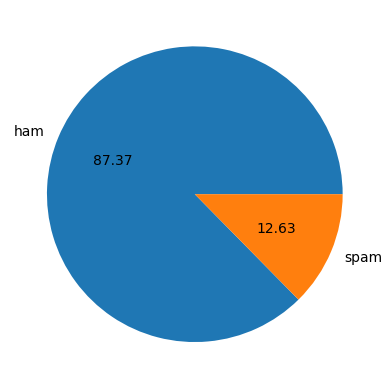

In [24]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [25]:
import nltk

In [26]:
!pip install nltk


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
#	Tokenizer model download karta hai
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\iaman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [28]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\iaman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [29]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\iaman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [30]:
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\iaman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [31]:
# #punkt ek tokenizer model hai jo sentence aur word ko todne ke kaam aata hai.
# from nltk.tokenize import word_tokenize
# text = "Hello world!"
# word_tokenize(text)  
# # Output: ['Hello', 'world', '!']
from nltk.tokenize import word_tokenize
print(word_tokenize("Hello world!"))



['Hello', 'world', '!']


In [32]:
df['num_characters'] = df['text'].apply(len)

In [33]:
df

,target,text,num_characters
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161
5568,ham,Will Ì_ b going to esplanade fr home?,37
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


In [34]:
#apply() har row te ek function lagata hai.

In [35]:
from nltk.tokenize import word_tokenize

x = "Hi, how are you?"
print(word_tokenize(x))



['Hi', ',', 'how', 'are', 'you', '?']


In [36]:
# num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [37]:
text = "Hello world!"
print(len(text))  # ➜ 12 (including space and punctuation)
#len(text) → counts each character (letters, space, symbols, etc.)

12


In [38]:
texts = ["Hi", "Good morning", "SMS Spam!", "Call me @ 10"]
for t in texts:
    print(f"'{t}' → {len(t)} characters")


'Hi' → 2 characters
'Good morning' → 12 characters
'SMS Spam!' → 9 characters
'Call me @ 10' → 12 characters


In [39]:
from nltk.tokenize import word_tokenize

#word_tokenize(text) → breaks sentence into words and punctuation
#len(...) gives number of tokens (words + symbols)
text = "Hello world!"
words = word_tokenize(text)
print(words)         # ['Hello', 'world', '!']
print(len(words))    # ➜ 3 words

['Hello', 'world', '!']
3


In [40]:
from nltk.tokenize import word_tokenize
texts = [
    "Hi",
    "Good morning",
    "SMS Spam!",
    "Call me @ 10",
    "Limited offer!!! Click now"
]
for t in texts:
    print(f"'{t}' → {len(word_tokenize(t))} words: {word_tokenize(t)}")

'Hi' → 1 words: ['Hi']
'Good morning' → 2 words: ['Good', 'morning']
'SMS Spam!' → 3 words: ['SMS', 'Spam', '!']
'Call me @ 10' → 4 words: ['Call', 'me', '@', '10']
'Limited offer!!! Click now' → 7 words: ['Limited', 'offer', '!', '!', '!', 'Click', 'now']


In [41]:
df = pd.read_csv('spam.csv', encoding='latin1')  # or utf-8, depending
df = df[['v1', 'v2']]  # select only required columns
df.columns = ['target', 'text']


In [42]:
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [43]:
df

,target,text,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1


In [44]:
import pandas as pd
import nltk
nltk.download('punkt')

from nltk.tokenize import sent_tokenize

texts = [
    "Hi there!",
    "Call me now. It's urgent.",
    "Are you coming? Let me know. Hurry!",
    "One sentence only.",
    "Offer valid. Buy fast!"
]

df3 = pd.DataFrame({'text': texts})
df3['num_sentences'] = df3['text'].apply(lambda x: len(sent_tokenize(x)))
print(df3)


                                  text  num_sentences
0                            Hi there!              1
1            Call me now. It's urgent.              2
2  Are you coming? Let me know. Hurry!              3
3                   One sentence only.              1
4               Offer valid. Buy fast!              2


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\iaman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [45]:
import pandas as pd
from nltk.tokenize import word_tokenize

data = {
    'text': [
        "Hi there!",
        "Congratulations, you've won a prize.",
        "Call me after class.",
        "Are you free tomorrow?",
        "Limited offer!!! Buy now!"
    ]
}

df4 = pd.DataFrame(data)

df4['num_characters'] = df4['text'].apply(len)
df4['num_words'] = df4['text'].apply(lambda x: len(word_tokenize(x)))

print(df4)


                                   text  num_characters  num_words
0                             Hi there!               9          3
1  Congratulations, you've won a prize.              36          8
2                  Call me after class.              20          5
3                Are you free tomorrow?              22          5
4             Limited offer!!! Buy now!              25          8


In [46]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5572.000000,5572.000000,5572.000000
mean,80.118808,18.699390,1.996411
std,59.690841,13.741932,1.520159
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.500000
75%,121.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


In [47]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


In [48]:
df

,target,text,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1


In [49]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

ModuleNotFoundError: No module named 'sklearn'

In [50]:
df['target']=encoder.fit_transform(df['target'])

NameError: name 'encoder' is not defined

In [51]:
df

,target,text,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1


In [52]:
df=df.drop_duplicates(keep='first')

In [53]:
df

,target,text,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1


In [54]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


In [55]:
# spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


In [56]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
import seaborn as sns

In [58]:
import matplotlib.pyplot as plt
plt.show()


In [59]:
print(df.columns)


Index(['target', 'text', 'num_characters', 'num_words', 'num_sentences'], dtype='object')


<Axes: >

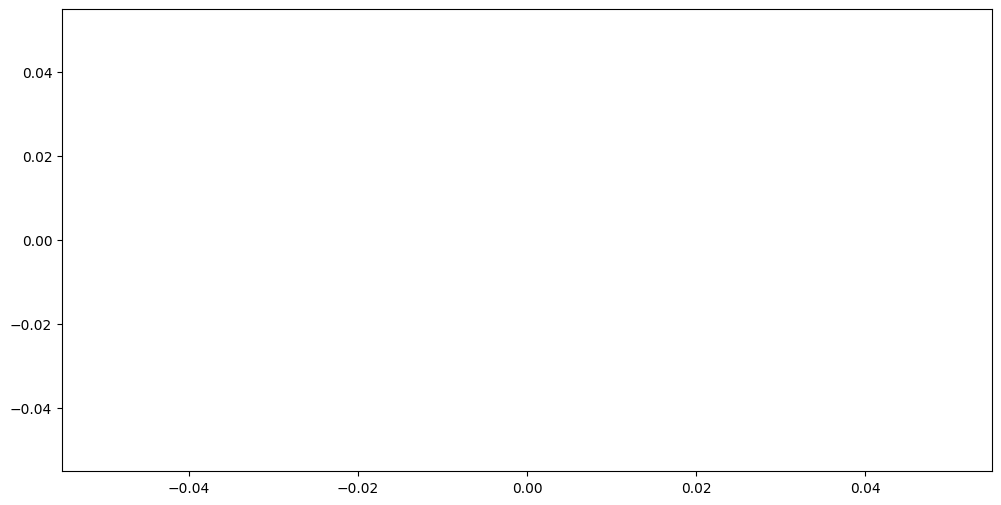

In [60]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

In [62]:
2+3

5

In [63]:
print(df['target'].unique())


['ham' 'spam']


In [64]:
df['target'] = df['target'].map({'ham': 0, 'spam': 1})


C:\Users\iaman\AppData\Local\Temp\ipykernel_22356\3225001897.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['target'] = df['target'].map({'ham': 0, 'spam': 1})


In [65]:
print(df[df['target'] == 0]['num_characters'].head())
print(df[df['target'] == 1]['num_characters'].head())


0    111
1     29
3     49
4     61
6     77
Name: num_characters, dtype: int64
2     155
5     148
8     158
9     154
11    136
Name: num_characters, dtype: int64


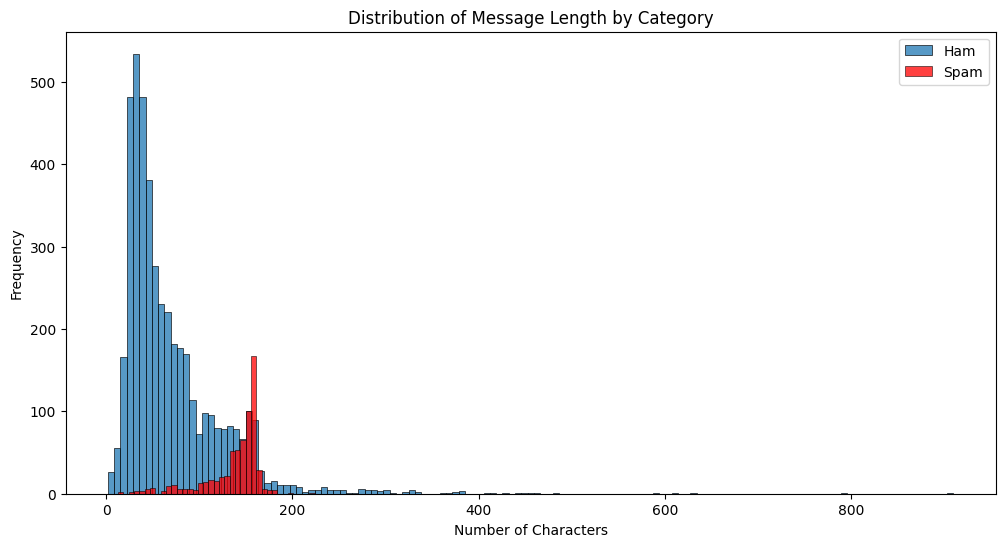

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

# Plot ham messages (target == 0)
sns.histplot(df[df['target'] == 0]['num_characters'], label='Ham', kde=False)

# Plot spam messages (target == 1)
sns.histplot(df[df['target'] == 1]['num_characters'], color='red', label='Spam', kde=False)

plt.title("Distribution of Message Length by Category")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.legend()  # legend works only when valid labels are present
plt.show()



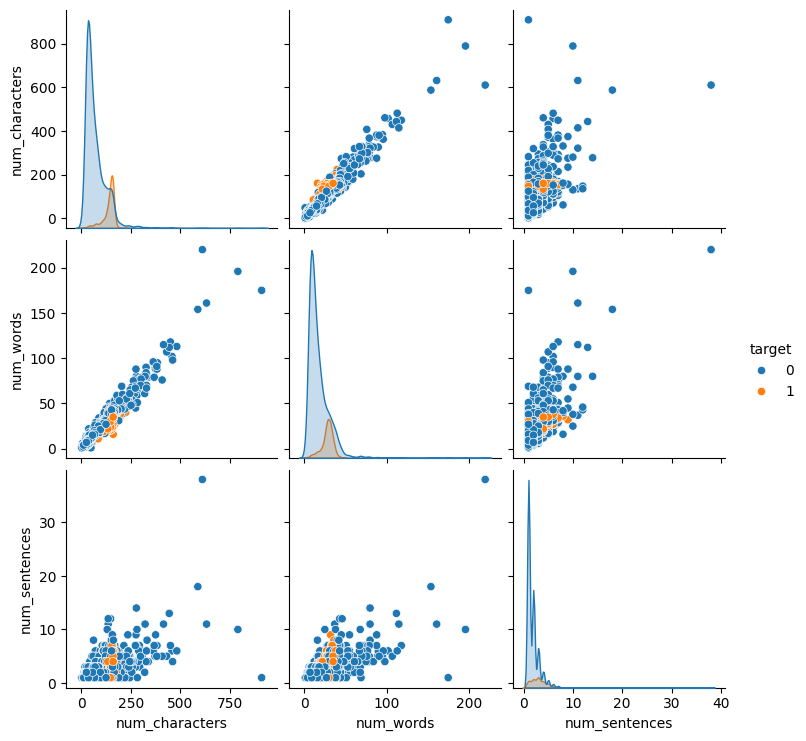

In [67]:
#pairplot ek scatter plot matrix banata hai:

#Jo bhi numeric columns hote hain dataframe (df) ke — un sab ke har possible pair ka scatter plot banata hai.
sns.pairplot(df,hue='target')

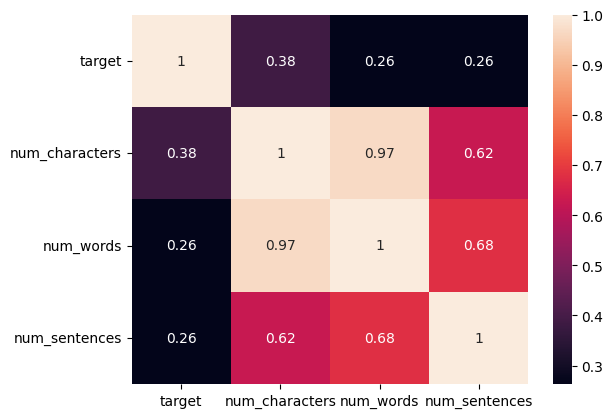

In [68]:
#df.corr()-Har do numerical column ka kis had tak ek dusre se sambandh hai – wo measure karta hai.Value range hoti hai -1 se 1 tak.
#+1.0->Strong positive correlation (Ek badhe to doosra bhi badhe).|| -1.0->Strong negative correlation (Ek badhe to doosra ghate)
#0.0->No correlation (Koi lena dena nahi)
#Jitna rang bright, utni zyada correlation , Jitna dull ya blue, utni kam ya negative correlation
#annot=True	Har box me number likha aata hai (correlation value)

#Select numeric columns only
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

## 3. Data Preprocessing

1.  Lower case2. 
Tokenization3.  
Removing special character4.  s
Removing stop words and punctuati5.  on
Stemming

In [69]:
import nltk
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer


In [70]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\iaman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [71]:
ps = PorterStemmer()

In [72]:
def transform_text(text):
    text = text.lower()  #Poora text lowercase me convert ho jaega
    text = nltk.word_tokenize(text) #Text ko shabdon me todta hai 
    
    y = []
    for i in text:
        if i.isalnum():  #isalnum() means: letters or numbers only,'@', ',', '!', '...' jaise symbols hata dega
            y.append(i)
    
    text = y[:]  #text me filtered words daal diye, y ko clear kiya aage use karne ke liye
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation: #Stopwords (jaise: 'is', 'the', 'and', 'a', 'you') aur punctuation fir se hata diye
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))  #ps.stem(i) = Porter Stemmer se word ka root form nikalte hain
    
            
    return " ".join(y)  #Final stemmed words ko space se jod kar ek string bana ke return karta hai

In [73]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [74]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [75]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [76]:
df['transformed_text'] = df['text'].apply(transform_text)

C:\Users\iaman\AppData\Local\Temp\ipykernel_22356\283536690.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transformed_text'] = df['text'].apply(transform_text)


In [77]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [78]:
!pip install wordcloud



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [79]:
#WordCloud class import ki gayi (text ka image banane ke liye).
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white') #Ek WordCloud object banaya with custom size and white background.

In [80]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
# Sirf spam messages ke cleaned text liye. Sab spam text ko ek string me joda (space se). Us string se WordCloud image generate kiya — jo words jyada repeat hue, wo image me bada dikhai denge.

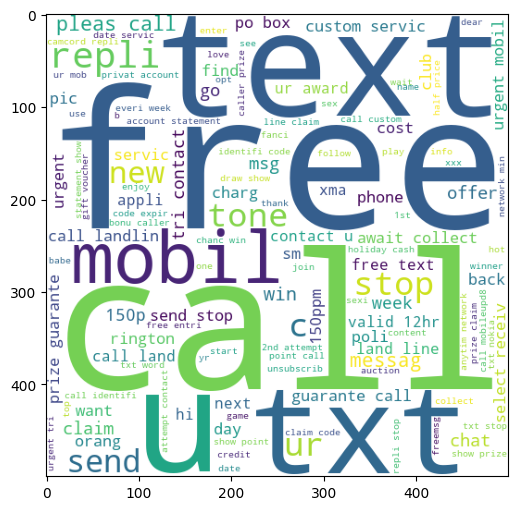

In [81]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [82]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

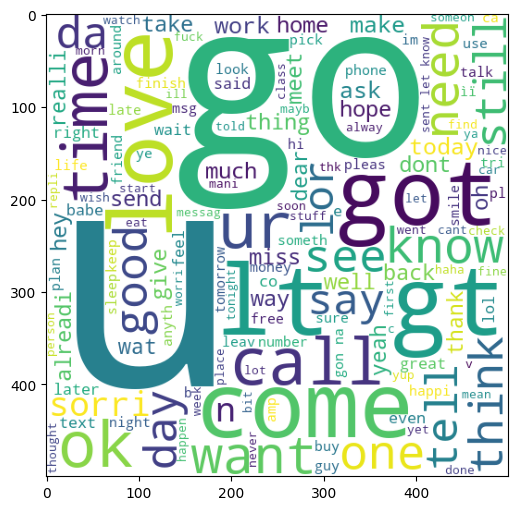

In [83]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [84]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [85]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [86]:
len(spam_corpus)

9939

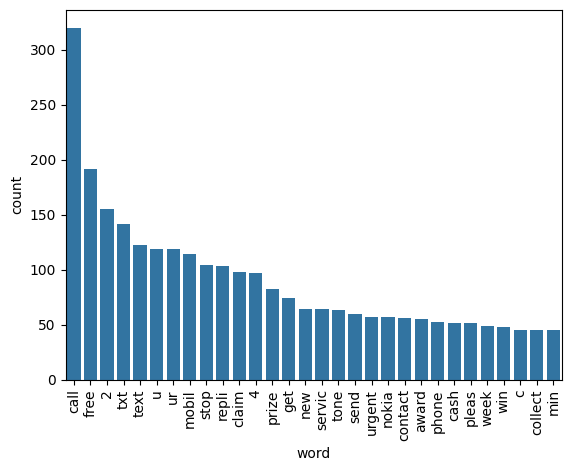

In [87]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Get top 30 words and their counts
top_30 = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

# Step 2: Plot
sns.barplot(x='word', y='count', data=top_30)
plt.xticks(rotation='vertical')
plt.show()


In [88]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [89]:
len(ham_corpus)

35404

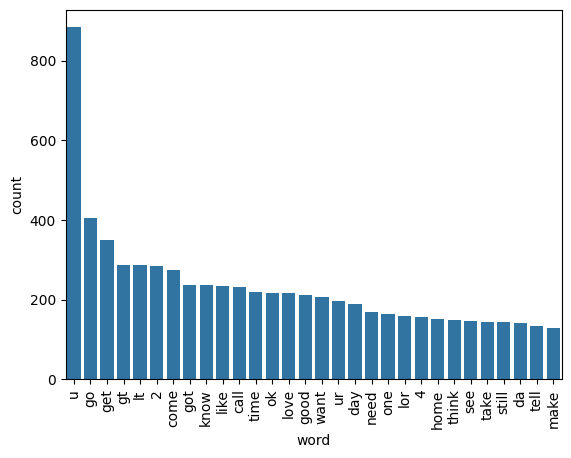

In [90]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Get top 30 words and their counts
top_30 = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])

# Step 2: Plot
sns.barplot(x='word', y='count', data=top_30)
plt.xticks(rotation='vertical')
plt.show()

In [91]:
# Text Vectorization
# using Bag of Words
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


##  4. Model Building

 #### ML model ke input me dena hai — lekin ML models text ko directly samajh nahi sakte. Unhe numbers (features) chahiye hote hain.

In [101]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer() #Har word ka count nikalta hai har message me.Ye har message ko bag of words me convert karta hai
tfidf = TfidfVectorizer(max_features=3000) #Har word ka importance score nikalta hai, Sirf top 3000 important words ko hi features banata hai — taaki model fast aur accurate ban sake.
#Ye sirf count nahi dekhta, balki:Ye check karta hai ki kaunsa word kitni jagah common hai.Agar koi word har jagah aa raha (jaise "the", "a", "you") — to uska importance kam kar deta hai.

In [102]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [103]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [104]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler() #	Features ko 0–1 range me scale karta hai
X = scaler.fit_transform(X) #Scaler ko data pe lagata hai

In [105]:
# appending the num_character col to X
X = np.hstack((X,df['num_characters'].values.reshape(-1,1))) #num_characters column (ek numeric feature) ko TF-IDF features ke saath jod raha hai
#X = Input features (text data converted to numbers)

In [106]:
X.shape

(5169, 3001)

In [107]:
y=df['target'].values

In [ ]:
#Hume model ko training data se sikhana padta hai.Phir testing data se dekhna padta hai ki model ne kitna accha seekha.
#train_test_split use karke:X aur y ko training aur testing parts me todti hai.
#X	Input features (jaise email ka transformed text in vector form — TF-IDF ya CountVectorizer se).y	Target/label (jaise 1 = spam, 0 = ham)

In [108]:
from sklearn.model_selection import train_test_split

In [109]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [110]:
#X_train → wo input data (features) jisse model ko train kiya jaayega. X_test → wo input data jisse model test hoga (dekhna ki model kaise perform kar raha).
#y_train → un inputs ke corresponding actual labels (spam ya ham) — training ke liye. y_test → test inputs ke labels — evaluation ke liye.

In [ ]:
#test_size=0.2 ,20% data test ke liye rakho.80% training, random_state=2 ,Har baar code run karne par same split milega, taaki results repeatable ho.

In [ ]:
#GaussianNB	Jab data continuous ho (jaise age, height) aur normal distribution ho	
#MultinomialNB	Jab data discrete/frequency-based ho — jaise bag-of-words, TF-IDF etc.	
#BernoulliNB	Jab data binary/boolean ho — 0 ya 1 values (word present or not)

In [112]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [111]:
#Ye teen cheezein help karti hain model evaluate karne me:
#accuracy_score-Kitne predictions sahi the out of total	Overall performance
#confusion_matrix-Ek matrix jo batata hai TP, TN, FP, FN kitne hain	Deep analysis
#precision_score-Out of predicted positives, kitne actually true the	Especially useful for spam detection jahan false positives dangerous hain

In [113]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [114]:
gnb.fit(X_train, y_train)                     # Model training
y_pred1 = gnb.predict(X_test)                 # Prediction
print(accuracy_score(y_test, y_pred1))        # Accuracy = (TP + TN) / Total
print(confusion_matrix(y_test, y_pred1))      # Confusion Matrix
print(precision_score(y_test, y_pred1))       # Precision


0.8907156673114119
[[800  96]
 [ 17 121]]
0.5576036866359447


In [ ]:
       #    Actual
      #   Ham     Spam
#Pred
#Ham     [808     88]
#Spam    [24     114]
#TP (True Positives)	114	Model predicted spam, and it was spam ✅
#TN (True Negatives)	808	Model predicted ham, and it was ham ✅
#FP (False Positives)	88	Model predicted spam, but it was actually ham ❌
#FN (False Negatives)	24	Model predicted ham, but it was actually spam ❌

In [115]:
#Precision: 0.56 → 56.4%, Out of all the messages predicted as spam, only 56.4% were actually spam.,Precision = TP / (TP + FP) #Tera model 89% accurate hai, lekin jab wo "spam" bolta hai, tab sirf 56% baar sahi hota hai — isliye kuch important "ham" messages bhi spam bol deta hai 😅

In [ ]:
#We're using GaussianNB, which is meant for continuous numeric data (e.g., age, height).
#But text data is frequency-based (like bag-of-words or TF-IDF), which suits MultinomialNB more.

In [116]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9738878143133463
[[890   6]
 [ 21 117]]
0.9512195121951219


In [118]:
bnb.fit(X_train, y_train)                  # Train Bernoulli Naive Bayes
y_pred3 = bnb.predict(X_test)             # Predict on test set

print(accuracy_score(y_test, y_pred3))    # Accuracy
print(confusion_matrix(y_test, y_pred3))  # Confusion Matrix
print(precision_score(y_test, y_pred3))   # Precision


0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [120]:
pip install xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/150.0 MB 2.8 MB/s eta 0:00:54
    --------------------------------------- 2.1/150.0 MB 6.2 MB/s eta 0:00:24
   -- ------------------------------------- 8.7/150.0 MB 16.3 MB/s eta 0:00:09
   ---- ----------------------------------- 16.5/150.0 MB 22.6 MB/s eta 0:00:06
   ------ --------------------------------- 24.1/150.0 MB 25.5 MB/s eta 0:00:05
   -------- ------------------------------- 32.5/150.0 MB 28.3 MB/s eta 0:00:05
   ---------- ----------------------------- 40.9/150.0 MB 29.6 MB/s eta 0:00:04
   ------------ --------------------------- 46.7/150.0 MB 30.9 MB/s eta 0:00:04
   ------------- -------------------------- 51.6/150.0 MB 29.1 MB/s eta 0:00:04
   --------------- ------------------------ 57.9/150.0 MB 29.1 MB/s eta 0:00:04
   ----------------- ---------------------- 65.0/150.0 MB 29.4


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier


In [ ]:
# LogisticRegression -> Linear model for classification	Simple and fast for binary classes (spam/ham)
# SVC -> Support Vector Classifier	Works well with small to medium datasets
# MultinomialNB	Naive Bayes for word count data	Great for text data + CountVectorizer/TFIDF
# DecisionTreeClassifier	->Decision-based splits	Easy to visualize, can overfit
# KNeighborsClassifier ->	K-Nearest Neighbors	Distance-based, needs scaling, slow on large data
# RandomForestClassifier ->	Multiple decision trees (ensemble)	Strong performance, handles noise well
# AdaBoostClassifier -> Adaptive boosting (focuses on wrong guesses)	Improves weak learners
# BaggingClassifier	Bootstrap aggregating	Reduces variance of models
# ExtraTreesClassifier	Like RF but more random	Faster and more diverse
# GradientBoostingClassifier->Boosted trees	Powerful, learns slowly to avoid overfitting
# XGBClassifier->eXtreme Gradient Boosting (XGBoost)	Super powerful, competition-winner model


In [122]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [123]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [124]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [126]:
svc = SVC(kernel='linear')
train_classifier(svc, X_train, y_train, X_test, y_test)


(0.9806576402321083, 0.9758064516129032)

In [127]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

C:\Users\iaman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


For  SVC
Accuracy -  0.8665377176015474
Precision -  0.0
For  KN
Accuracy -  0.8858800773694391
Precision -  0.8333333333333334
For  NB
Accuracy -  0.9738878143133463
Precision -  0.9512195121951219
For  DT
Accuracy -  0.9458413926499033
Precision -  0.8867924528301887
For  LR
Accuracy -  0.965183752417795
Precision -  0.9553571428571429
For  RF
Accuracy -  0.9690522243713733
Precision -  0.9818181818181818
For  AdaBoost
Accuracy -  0.9468085106382979
Precision -  0.9029126213592233
For  BgC
Accuracy -  0.9661508704061895
Precision -  0.8992248062015504
For  ETC
Accuracy -  0.9787234042553191
Precision -  0.9754098360655737
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.9700193423597679
Precision -  0.9495798319327731


In [128]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [129]:
performance_df

,Algorithm,Accuracy,Precision
5,RF,0.969052,0.981818
8,ETC,0.978723,0.975410
4,LR,0.965184,0.955357
2,NB,0.973888,0.951220
10,xgb,0.970019,0.949580
9,GBDT,0.950677,0.930693
6,AdaBoost,0.946809,0.902913
7,BgC,0.966151,0.899225
3,DT,0.945841,0.886792
1,KN,0.885880,0.833333


In [130]:
#Wide data ko long format me convert karna
#pd.melt(performance_df, id_vars='Algorithm') karne ke baad: Har classifier ke 2 row ban jaate hain — ek Accuracy ke liye, ek Precision ke liye.
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [131]:
performance_df1

,Algorithm,variable,value
0,RF,Accuracy,0.969052
1,ETC,Accuracy,0.978723
2,LR,Accuracy,0.965184
3,NB,Accuracy,0.973888
4,xgb,Accuracy,0.970019
5,GBDT,Accuracy,0.950677
6,AdaBoost,Accuracy,0.946809
7,BgC,Accuracy,0.966151
8,DT,Accuracy,0.945841
9,KN,Accuracy,0.885880


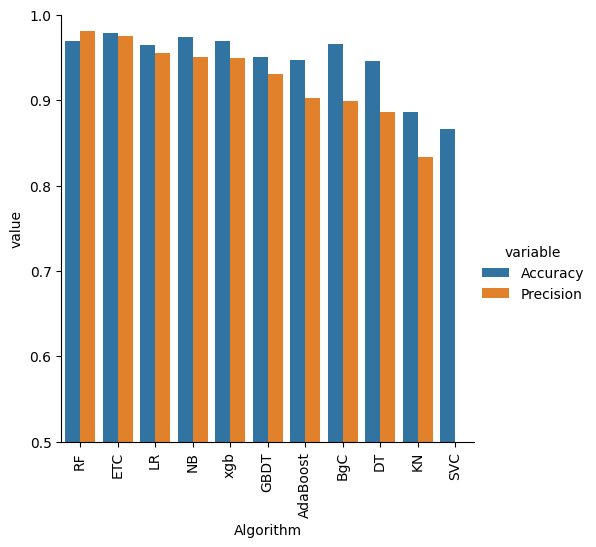

In [132]:
sns.catplot(x = 'Algorithm', y='value', 
            hue = 'variable', data=performance_df1, kind='bar', height=5)

plt.ylim(0.5, 1.0) #Ye plot ki vertical range fix karta hai: Matlab Y-axis sirf 0.5 se 1.0 ke darmiyan dikhayega.
plt.xticks(rotation='vertical') #X-axis ke labels (classifiers ke naam) ko seedha (vertical) ghooma diya gaya hai, taake naam clearly dikh sakein aur overlap na ho.
plt.show()


In [134]:
# jab TfidfVectorizer(max_features=3000) use kiya tha — yani feature selection kiya tha.
temp_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_max_ft_3000': accuracy_scores,
    'Precision_max_ft_3000': precision_scores
})


In [136]:
#Ye tab hai jab tumne feature scaling kiya ho — jaise MinMaxScaler() ya StandardScaler()Matlab ab tum check kar rahe ho ki scaling ke baad performance kaise badli.
#check kiya jaata hai  Kaunsa algorithm + kaunsi feature engineering technique sabse behtareen combo hai.
temp_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_scaling': accuracy_scores,
    'Precision_scaling': precision_scores
}).sort_values('Precision_scaling', ascending=False)


In [145]:
#| Algorithm | Accuracy | Precision | Accuracy\_scaling | Precision\_scaling |
#| --------- | -------- | --------- | ----------------- | ------------------ |

new_df = performance_df.merge(temp_df,on='Algorithm')

In [146]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [147]:
temp_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_num_chars': accuracy_scores,
    'Precision_num_chars': precision_scores
}).sort_values('Precision_num_chars', ascending=False)

In [148]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_num_chars_x,Precision_num_chars_x,Accuracy_num_chars_y,Precision_num_chars_y,Accuracy_num_chars,Precision_num_chars
0,RF,0.969052,0.981818,0.969052,0.981818,0.969052,0.981818,0.969052,0.981818
1,ETC,0.978723,0.975410,0.978723,0.975410,0.978723,0.975410,0.978723,0.975410
2,LR,0.965184,0.955357,0.965184,0.955357,0.965184,0.955357,0.965184,0.955357
3,NB,0.973888,0.951220,0.973888,0.951220,0.973888,0.951220,0.973888,0.951220
4,xgb,0.970019,0.949580,0.970019,0.949580,0.970019,0.949580,0.970019,0.949580
5,GBDT,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693
6,AdaBoost,0.946809,0.902913,0.946809,0.902913,0.946809,0.902913,0.946809,0.902913
7,BgC,0.966151,0.899225,0.966151,0.899225,0.966151,0.899225,0.966151,0.899225
8,DT,0.945841,0.886792,0.945841,0.886792,0.945841,0.886792,0.945841,0.886792
9,KN,0.885880,0.833333,0.885880,0.833333,0.885880,0.833333,0.885880,0.833333


In [149]:
#Voting Classifier ek ensemble learning technique hai, jisme hum multiple models (classifiers) ko mila ke final decision lete hain — jaise:
#Agar zyada models kahein ki yeh spam hai, to maan lenge ki yeh spam hi hai.
# 3 alag-alag classifiers define kiye gaye hain:

svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
#Ye Extra Trees Classifier hai — Random Forest jaise hi hota hai, lekin ye aur randomness laata hai:n_estimators=50 → 50 decision trees banayega.
#random_state=2 → result same aaye baar-baar run karne pe (reproducibility).

# VotingClassifier module ko import kiya
from sklearn.ensemble import VotingClassifier


In [150]:
#kernel='sigmoid' : sigmoid kernel lagaya gaya hai, jo nonlinear boundary create karta hai (curve line decision).
#gamma=1.0 : gamma controls how far the influence of a single training example reaches.
#probability=True : taake ye classifier soft voting mein use ho sake (ye probabilities dega).

In [151]:
voting = VotingClassifier(estimators=[
    ('svc', svc),
    ('mnb', mnb),
    ('etc', etc)
], voting='soft')  # ya 'hard'


In [152]:
voting.fit(X_train,y_train)

,estimators,"[('svc', ...), ('mnb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [153]:
#X_train: Features — yani ke tumhara input data (jaise email text features: word counts, tf-idf, etc.).
#y_train: Labels — matlab spam ya ham jaisa target column.
#.fit() method: Ye har base model ko individually train karta hai:
#svc.fit(X_train, y_train) , mnb.fit(X_train, y_train) , etc.fit(X_train, y_train
#.predict() call karoge, toh ye teenon ke prediction ko combine karke majority vote ya average probability le ke final output dega.

In [168]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9738878143133463
Precision 1.0


In [169]:
#Jab base models prediction de dete hain (e.g. SVM → spam, NB → ham, ETC → spam),#Toh ye final_estimator in teeno ke predictions ko input features ki tarah use karke final decision leta hai.
#StackingClassifier naam ka ek tool import kar rahi hai jo multiple algorithms ko combine karke ek stronger model banata hai
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [170]:
from sklearn.ensemble import StackingClassifier

In [171]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [172]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9738878143133463
Precision 0.9111111111111111


In [174]:
import pickle
#pickle Python ka ek built-in module hai jo objects ko serialize karne ke kaam aata hai.🧠 Serialize ka matlab:
#Object (jaise model, vectorizer) ko ek file mein convert karna — taki usse baad mein dubara load karke use kiya ja sake.
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
#Yeh tfidf vectorizer ko 'vectorizer.pkl' file mein save kar raha hai.
#dump() = save karna
#open('vectorizer.pkl', 'wb') = file banai ja rahi hai write binary ('wb') mode mein
#'vectorizer.pkl' = is naam ki file banegi jisme vectorizer hoga
pickle.dump(mnb, open('model.pkl', 'wb'))
#Yeh trained MultinomialNB model ko 'model.pkl' file mein save kar raha hai.
#Matlab: tumne spam detection ya koi aur task ke liye model train kiya tha — ab wo ready model file mein save ho gaya.
#🧠 Fayda?Ab baar-baar train karne ki zarurat nahi — sirf load karo aur use karo.

In [175]:
from sklearn.naive_bayes import MultinomialNB
import pickle

# Assume X_train, y_train already defined
model = MultinomialNB()
model.fit(X_train, y_train)  # ✅ Model trained

# Save the trained model
pickle.dump(model, open('model.pkl', 'wb'))

# Also save the fitted vectorizer
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))


In [176]:
import sys
print(sys.executable)


C:\Users\iaman\AppData\Local\Programs\Python\Python310\python.exe


In [180]:
from sklearn.naive_bayes import MultinomialNB
import pickle

# Assume X_train, y_train already defined
mnb = MultinomialNB()
mnb.fit(X_train, y_train)  # ✅ Ye zaruri hai!

# Save trained model
pickle.dump(mnb, open('model.pkl', 'wb'))


In [181]:
# Step 1: Vectorizer
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()

# Step 2: Add num_characters
X = np.hstack((X, df['num_characters'].values.reshape(-1, 1)))  # Now X has 3001 features

# Step 3: Train model
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
mnb.fit(X, y)

# Step 4: Save everything
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))
